In [1]:
%load_ext autoreload
%autoreload 2
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

import numpy as np
from datetime import datetime, timezone

import atmo3 as a3

import pycraf
from astropy import units as u

from scipy import constants

import matplotlib.pyplot as plt
import numpy as np

# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [2]:


# ==========================================
# --- 1. Grid & Simulation Setup ---
# ==========================================
nside_grid = [2, 2, 1024]
box_length = [20000., 20000., 50000.]

freqs = jnp.linspace(1., 300., num=300) # Frequencies in GHz

site_altitude = 5100.
site_coordinates = [-67.78, -22.95] 
time_utc = datetime(2023, 9, 16, 0, 0, tzinfo=timezone.utc)

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
o3file     = f'{atmo3_data}era5/2023/o3.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
apexfile   = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

# Initialize Atmosphere
atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)

# Extract Thermodynamic Profiles
ds = atmo_box.grid_wsp.grid_spacing[2] * jnp.ones((nside_grid[2],))
T = atmo_box.atm_calibrator.temperature_profile
P = atmo_box.atm_calibrator.pressure

# Base water vapor profile
rho_w_base = atmo_box.atm_calibrator.q2rho_h2o * atmo_box.atm_calibrator.spec_humidity_profile

# Ozone Setup
o3_profile_1d = atmo_box.super_grid.era5_interp2site(o3file)
M_air = 28.9647e-3 
M_o3 = 47.9982e-3  
vmr_o3 = o3_profile_1d * (M_air / M_o3)
P_o3 = vmr_o3 * P 

# Vectorized attenuation functions
vmap_attenuation = jax.vmap(a3.compute_attenuation_water_vapor_am, in_axes=(0, 0, 0, None), out_axes=1)
vmap_attenuation_dry = jax.vmap(a3.compute_attenuation_dry_air_am, in_axes=(0, 0, 0, None), out_axes=1)
vmap_attenuation_o3 = jax.vmap(a3.compute_attenuation_ozone_am, in_axes=(0, 0, 0, 0, None), out_axes=1)

gamma_wet = vmap_attenuation(T, P, rho_w_base, freqs)
gamma_dry = vmap_attenuation_dry(T, P, rho_w_base, freqs)
gamma_o3  = vmap_attenuation_o3(T, P, P_o3, rho_w_base, freqs)

# Total Attenuation and Transmission
total_attenuation = gamma_wet + gamma_dry + gamma_o3 #(Nf, Nz)


d_tau = total_attenuation * (ds[None, :] / 1000.0) * (jnp.log(10.0) / 10.0)

# 3. Integrate vertically (cumulative sum from ground z=0 up to layer z)
# Shape remains (Nf, Nz)
tau_zenith = jnp.cumsum(d_tau, axis=1) 

1.1099999999999999 0.0607453701939497


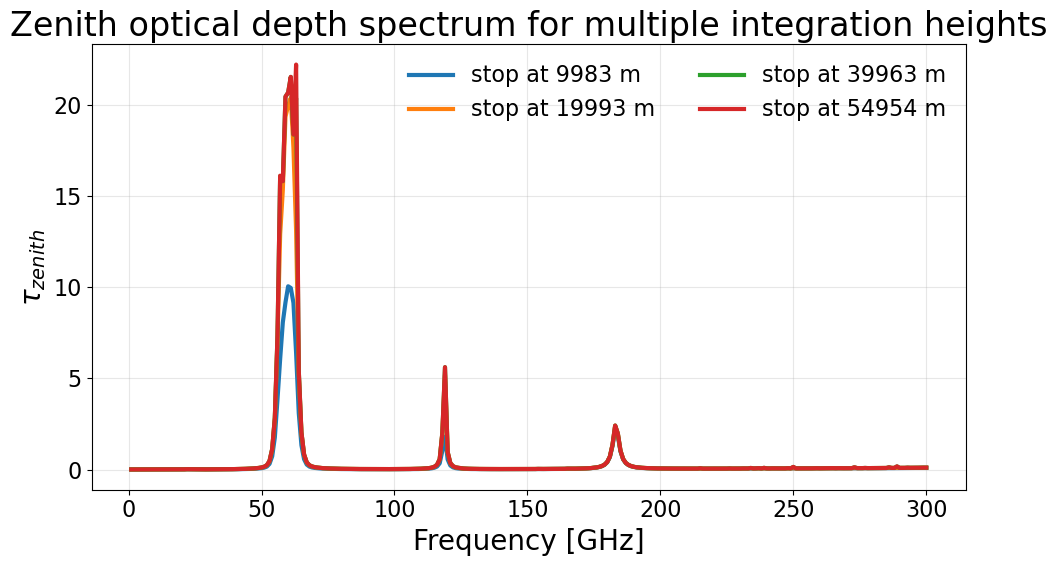

In [3]:
# Frequency spectrum of tau_zenith for multiple stopping altitudes
# Edit these values to choose where the vertical integration stops.
integration_altitudes_m = np.array([10000, 20000, 40000, 55000])

freqs_ghz = np.asarray(freqs)
tau_zenith_np = np.asarray(tau_zenith)
z_axis_m = site_altitude + np.cumsum(np.asarray(ds))

fig, ax = plt.subplots(figsize=(10, 6))

for stop_altitude_m in integration_altitudes_m:
    stop_idx = int(np.clip(np.searchsorted(z_axis_m, stop_altitude_m, side="right") - 1, 0, len(z_axis_m) - 1))
    ax.plot(
        freqs_ghz,
        tau_zenith_np[:, stop_idx],
        label=f"stop at {z_axis_m[stop_idx]:.0f} m",
    )

ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel(r"$\tau_{zenith}$")
ax.set_title("Zenith optical depth spectrum for multiple integration heights")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

In [14]:


pi = constants.pi 
c = constants.c
rho_ice = 917 # kg/m^3

# Assuming atmo_box is already initialized
altitude = atmo_box.grid_wsp.grid_axis(axis=2, altitude_axis=True)
dz = altitude[1] - altitude[0] # Calculate actual vertical grid spacing

elevation = 45 # degrees
IWP = 1e-3 # Target IWP: 1 g/m^2 in kg/m^2

layer_bottom = 6000  # Bottom of the ice cloud layer in meters
layer_top = 7000     # Top of the ice cloud layer in meters

# 1. Create a boolean mask for the specific layers
cloud_mask = (altitude >= layer_bottom) & (altitude <= layer_top)

# 2. Calculate the TRUE discrete thickness based on the grid
true_thickness = np.sum(cloud_mask) * dz

# 3. Calculate d(IWP)/dz (which is the Ice Water Content)
# Using true_thickness ensures np.sum(IWC_profile) * dz == target IWP
IWC_constant = IWP / true_thickness # kg/m^3

# Create the IWC profile (0 everywhere except in the cloud mask)
IWC_profile = np.where(cloud_mask, IWC_constant, 0.0)

r_eq_ice = np.array([30e-6]) # equivalent radius in meters

# 4. Compute Volume of the crystals for all radii
V_ice = (4.0 / 3.0) * np.pi * r_eq_ice**3 # Shape: (Na,)

# 5. Compute the ice density n(z, r_eq) using Broadcasting
# [:, None] makes IWC a column (Nz, 1) 
# [None, :] makes V a row (1, Na)
n_ice = IWC_profile[:, None] / (rho_ice * V_ice[None, :])

m_ice = np.array([0.2, 0.6, 1.0, 3.0, 5.0]) # aspect ratios for ice crystals

LWP = 100e-3 #Target LWP: 1 g/m^2 in kg/m^2

rho_liquid = 1000 # kg/m^3

LWC_constant = LWP / true_thickness # kg/m^3
LWC_profile = np.where(cloud_mask, LWC_constant, 0.0)

r_eq_liquid = np.array([10e-6]) # equivalent radius in meters

V_liquid = (4.0 / 3.0) * np.pi * r_eq_liquid**3 # Shape: (Na,)

n_liquid = LWC_profile[:, None] / (rho_liquid * V_liquid[None, :])

m_liquid = np.array([1.0]) # Shape: (Na,)

In [15]:
from atmo3.ice_emission import get_particle_emission, get_particle_scattering

# ==============================================================================
# 1. Adapt the Shapes for the JAX Functions (Adding the n_scans=1 dimension)
# ==============================================================================

# Temperature and step size: (Nz,) -> (1, Nz)
T_los = T[None, :] 
ds_los = ds[None, :] 

# Particle densities: Your n_ice is (Nz, 1). Transposing gives (1, Nz)
n_ice_los = n_ice.T 
n_liquid_los = n_liquid.T

# Optical depth: (Nf, Nz) -> (1, Nf, Nz)
tau_zenith_3d = tau_zenith[None, :, :]

# Total zenith optical depth (extract the top of the atmosphere for all freqs)
# Shape needs to be (1, Nf, 1) to broadcast correctly against (1, Nf, Nz)
tau_total_zenith = tau_zenith[:, -1][None, :, None]

# Extract scalar radii
r_ice_scalar = float(r_eq_ice[0])
r_liquid_scalar = float(r_eq_liquid[0])


# ==============================================================================
# 2. Compute Signals for ICE
# ==============================================================================
print("--- COMPUTING ICE SIGNALS ---")

# Create a dictionary to hold all the results
results_ice = {}

for m in m_ice:
    m_scalar = float(m)
    print(f"\nIce Aspect Ratio (m) = {m_scalar}")
    
    # A. Emission Only
    I_emit_ice, Q_emit_ice = get_particle_emission(
        T_los, n_ice_los, r_ice_scalar, tau_zenith_3d, ds_los, freqs, m_scalar, elevation, is_liquid=False
    )
    
    # B. Scattering (Ground Only - No Atmospheric Downwelling)
    I_scat_gnd_ice, Q_scat_gnd_ice = get_particle_scattering(
        T_los, n_ice_los, r_ice_scalar, ds_los, freqs, m_scalar, elevation, 
        tau_zenith_3d, tau_total_zenith, 
        consider_atmospheric_emission=False, is_liquid=False
    )
    
    # C. Scattering (Ground + Atmospheric Downwelling)
    I_scat_full_ice, Q_scat_full_ice = get_particle_scattering(
        T_los, n_ice_los, r_ice_scalar, ds_los, freqs, m_scalar, elevation, 
        tau_zenith_3d, tau_total_zenith, 
        consider_atmospheric_emission=True, is_liquid=False
    )

    # Store the 1D arrays (extracting via [0] to remove the n_scans dimension)
    results_ice[m_scalar] = {
        'I_emit': I_emit_ice[0],
        'Q_emit': Q_emit_ice[0],
        'I_scat_gnd': I_scat_gnd_ice[0],
        'Q_scat_gnd': Q_scat_gnd_ice[0],
        'I_scat_full': I_scat_full_ice[0],
        'Q_scat_full': Q_scat_full_ice[0]
    }

# ==============================================================================
# 3. Compute Signals for LIQUID WATER
# ==============================================================================
print("\n--- COMPUTING LIQUID WATER SIGNALS ---")

# Create a dictionary to hold liquid results
results_liquid = {}

for m in m_liquid:
    m_scalar = float(m)
    print(f"\nLiquid Aspect Ratio (m) = {m_scalar}")
    
    # A. Emission Only
    I_emit_liq, Q_emit_liq = get_particle_emission(
        T_los, n_liquid_los, r_liquid_scalar, tau_zenith_3d, ds_los, freqs, m_scalar, elevation, is_liquid=True
    )
    
    # B. Scattering (Ground Only)
    I_scat_gnd_liq, Q_scat_gnd_liq = get_particle_scattering(
        T_los, n_liquid_los, r_liquid_scalar, ds_los, freqs, m_scalar, elevation, 
        tau_zenith_3d, tau_total_zenith, 
        consider_atmospheric_emission=False, is_liquid=True
    )
    
    # C. Scattering (Ground + Atmospheric Downwelling)
    I_scat_full_liq, Q_scat_full_liq = get_particle_scattering(
        T_los, n_liquid_los, r_liquid_scalar, ds_los, freqs, m_scalar, elevation, 
        tau_zenith_3d, tau_total_zenith, 
        consider_atmospheric_emission=True, is_liquid=True
    )

    # Store the 1D arrays
    results_liquid[m_scalar] = {
        'I_emit': I_emit_liq[0],
        'Q_emit': Q_emit_liq[0],
        'I_scat_gnd': I_scat_gnd_liq[0],
        'Q_scat_gnd': Q_scat_gnd_liq[0],
        'I_scat_full': I_scat_full_liq[0],
        'Q_scat_full': Q_scat_full_liq[0]
    }

--- COMPUTING ICE SIGNALS ---

Ice Aspect Ratio (m) = 0.2

Ice Aspect Ratio (m) = 0.6

Ice Aspect Ratio (m) = 1.0

Ice Aspect Ratio (m) = 3.0

Ice Aspect Ratio (m) = 5.0

--- COMPUTING LIQUID WATER SIGNALS ---

Liquid Aspect Ratio (m) = 1.0


In [16]:
from atmo3.ice_emission import intensitySI_to_Tb

# ==============================================================================
# Convert Ice Signals to Brightness Temperature
# ==============================================================================
Tb_results_ice = {}

for m, signals in results_ice.items():
    Tb_results_ice[m] = {}
    for key, I_nu in signals.items():
        # Convert each intensity array to Brightness Temperature (K)
        Tb_results_ice[m][key] = intensitySI_to_Tb(I_nu, freqs)

# ==============================================================================
# Convert Liquid Water Signals to Brightness Temperature
# ==============================================================================
Tb_results_liquid = {}

for m, signals in results_liquid.items():
    Tb_results_liquid[m] = {}
    for key, I_nu in signals.items():
        # Convert each intensity array to Brightness Temperature (K)
        Tb_results_liquid[m][key] = intensitySI_to_Tb(I_nu, freqs)

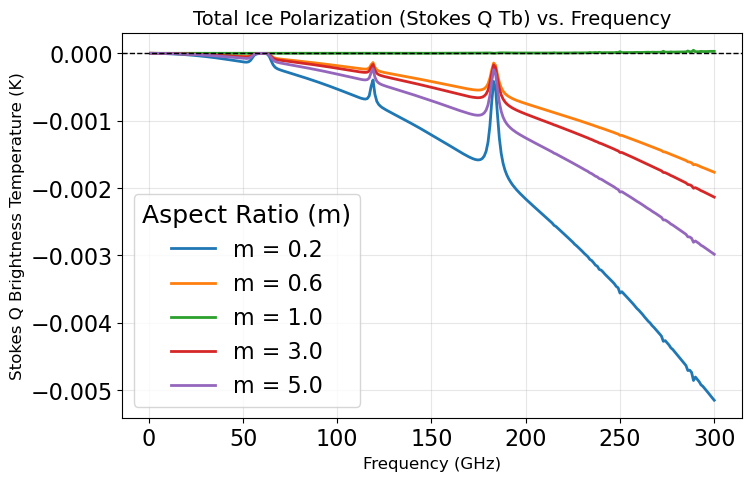

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
for m in m_ice:
    m_scalar = float(m)
    # Total Q (Tb) is Emission + Full Scattering
    Q_total_Tb = Tb_results_ice[m_scalar]['Q_emit'] + Tb_results_ice[m_scalar]['Q_scat_full']
    plt.plot(freqs, Q_total_Tb, label=f'm = {m_scalar}', linewidth=2)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Total Ice Polarization (Stokes Q Tb) vs. Frequency', fontsize=14)
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('Stokes Q Brightness Temperature (K)', fontsize=12)
plt.legend(title='Aspect Ratio (m)')
plt.grid(True, alpha=0.3)
plt.show()

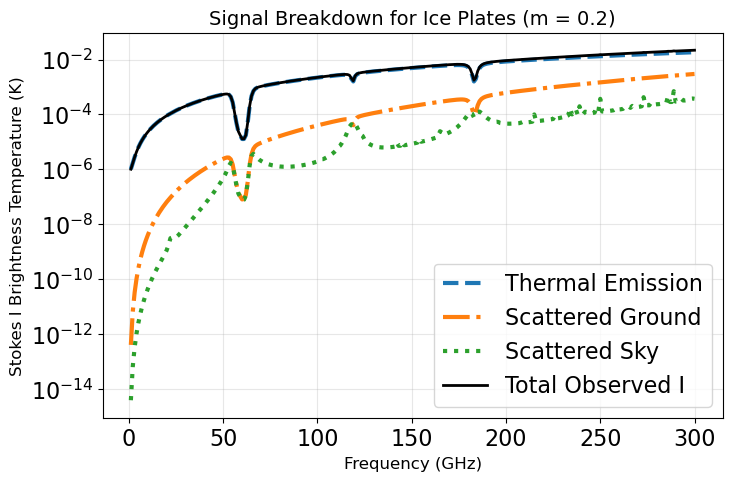

In [21]:
plt.figure(figsize=(8, 5))
m_target = 0.2 # Look at thin plates

Tb_emit = Tb_results_ice[m_target]['I_emit']
Tb_scat_gnd = Tb_results_ice[m_target]['I_scat_gnd']
Tb_scat_sky = Tb_results_ice[m_target]['I_scat_full'] - Tb_results_ice[m_target]['I_scat_gnd']
Tb_total = Tb_emit + Tb_results_ice[m_target]['I_scat_full']

plt.plot(freqs, Tb_emit, label='Thermal Emission', linestyle='--')
plt.plot(freqs, Tb_scat_gnd, label='Scattered Ground', linestyle='-.')
plt.plot(freqs, Tb_scat_sky, label='Scattered Sky', linestyle=':')
plt.plot(freqs, Tb_total, label='Total Observed I', color='black', linewidth=2)

plt.title(f'Signal Breakdown for Ice Plates (m = {m_target})', fontsize=14)
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('Stokes I Brightness Temperature (K)', fontsize=12)
plt.yscale('log') 
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

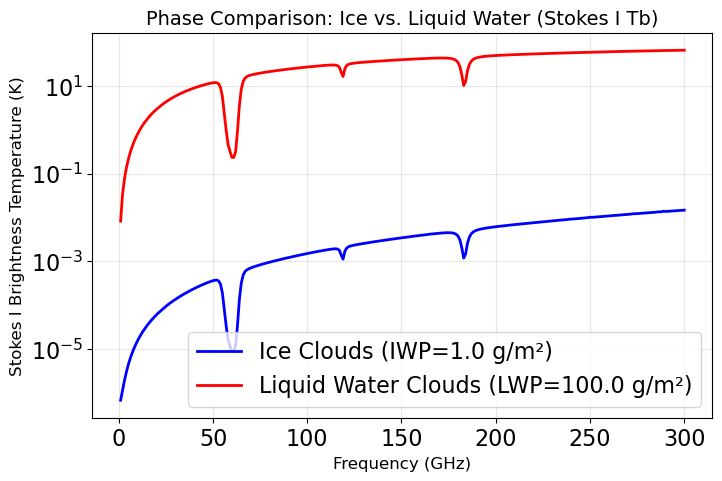

In [20]:
plt.figure(figsize=(8, 5))

# Ice spheres (m=1.0)
Tb_total_ice = Tb_results_ice[1.0]['I_emit'] + Tb_results_ice[1.0]['I_scat_full']

# Liquid spheres (m=1.0)
Tb_total_liq = Tb_results_liquid[1.0]['I_emit'] + Tb_results_liquid[1.0]['I_scat_full']

plt.plot(freqs, Tb_total_ice, label=f'Ice Clouds (IWP={IWP*1000:.1f} g/m²)', color='blue', linewidth=2)
plt.plot(freqs, Tb_total_liq, label=f'Liquid Water Clouds (LWP={LWP*1000:.1f} g/m²)', color='red', linewidth=2)

plt.title('Phase Comparison: Ice vs. Liquid Water (Stokes I Tb)', fontsize=14)
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('Stokes I Brightness Temperature (K)', fontsize=12)
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

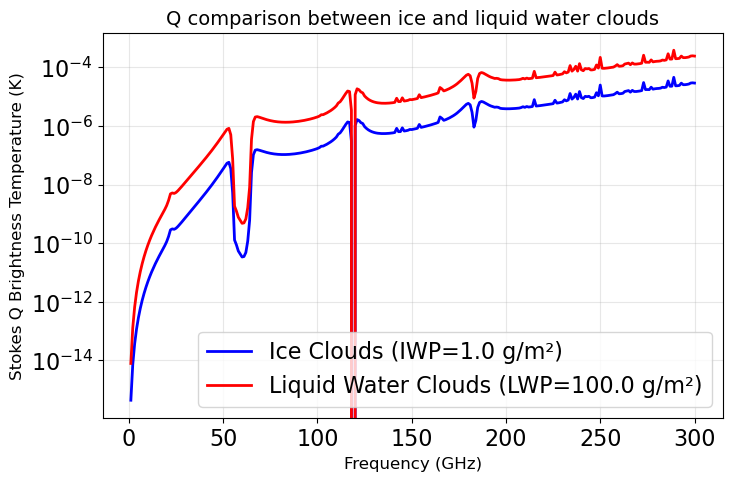

In [22]:
Q_total_liq = Tb_results_liquid[1.0]['Q_emit'] + Tb_results_liquid[1.0]['Q_scat_full']
Q_total_ice = Tb_results_ice[1.0]['Q_emit'] + Tb_results_ice[1.0]['Q_scat_full']

plt.figure(figsize=(8, 5))

plt.plot(freqs, Q_total_ice, label=f'Ice Clouds (IWP={IWP*1000:.1f} g/m²)', color='blue', linewidth=2)
plt.plot(freqs, Q_total_liq, label=f'Liquid Water Clouds (LWP={LWP*1000:.1f} g/m²)', color='red', linewidth=2)
plt.title('Q comparison between ice and liquid water clouds', fontsize=14)
plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('Stokes Q Brightness Temperature (K)', fontsize=12)
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
print(Tb_results_liquid[1.0]['Q_emit'])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
"""
#If we want to use pycraf

altitudes = np.linspace(1, 10000, 500) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa
dz = np.diff(altitudes) # Shape: (len(altitudes)-1,)
frequency_ghz = np.arange(1, 999, 3) # GHz   
frequency = frequency_ghz * 1e9 # Hz
"""